# KDHS 2022 — Contraceptive Use Prediction
## Data Cleaning, EDA, Modelling & Deployment
### The Insight Architects Group

---

**Dataset:** Kenya Demographic and Health Survey (KDHS) 2022 — Women's Questionnaire  
**Respondents:** 32,156 women aged 15–49 across all 47 counties  
**Target Variable:** `contraceptive_use` — Type of contraceptive method currently used  
**Methodology:** CRISP-DM  
**Tools:** Python · scikit-learn · LightGBM · SHAP · Flask

---

## 1. Business Understanding

### 1.1 Business Overview
Kenya has made significant progress in family planning over the past three decades, yet contraceptive uptake remains deeply unequal across the country's 47 counties. The 2022 Kenya Demographic and Health Survey (KDHS), a nationally representative dataset of 32,156 women aged 15–49, captures this inequality in detail — recording sociodemographic variables such as education, wealth, residence, marital status, and county of residence alongside contraceptive use patterns. Since manual analysis of such a large, multi-variable dataset is impractical for health planners, machine learning can be used to automatically identify the sociodemographic profiles of women most at risk of contraceptive non-use.

This project develops a contraceptive use prediction model using the 2022 KDHS dataset to help the Ministry of Health and family planning partners identify underserved population segments and deploy targeted interventions efficiently and at scale.

### 1.2 Problem Statement
Kenya's modern contraceptive prevalence rate among married women is approximately 60% nationally, but this average conceals major geographic and socioeconomic inequalities. In arid and semi-arid counties such as Turkana, West Pokot, and Mandera, contraceptive uptake falls 20–30 percentage points below the national average, while more urbanised counties like Nairobi and Kiambu report markedly higher rates. Without a data-driven segmentation of at-risk populations, health interventions are distributed uniformly rather than targeted where they are needed most.

**Key challenges include:**
- **Class imbalance** — modern method users (38%) significantly outnumber folkloric and traditional method users (4% combined)
- **High dimensionality** — 5,925 variables in the raw survey requiring careful feature selection down to the most relevant predictors
- **Multicollinearity** — closely related variables such as age, children ever born, and marital status overlap in predictive power
- **Categorical encoding** — ordinal variables like wealth index and education level require careful treatment to preserve their natural ordering

**Objective:** Build a model that accurately predicts contraceptive use among Kenyan women aged 15–49 using sociodemographic features, and identify which factors most strongly drive or prevent modern contraceptive uptake.

### 1.3 Stakeholders

| Stakeholder | How They Use This Model |
|---|---|
| Kenya Ministry of Health — Division of Reproductive Health | Identify counties and demographic groups with highest predicted non-use; allocate field officers and resources accordingly |
| County Health Management Teams (all 47 counties) | Generate county-specific risk profiles to guide local family planning outreach programmes |
| UNFPA Kenya Country Office | Target funding and technical assistance toward highest-risk population segments |
| USAID Kenya | Use model outputs to evaluate programme effectiveness and redirect investments to underserved regions |
| FP2030 Programme | Monitor progress toward family planning targets by tracking predicted non-use rates over time |
| Community Health Promoters (CHPs) | Use county-level risk scores to prioritise household visits in high-risk clusters |

### 1.4 Success Metrics
The model will be considered successful if:
- **Accuracy ≥ 78%** on the held-out test set
- **ROC-AUC ≥ 0.82**, measuring the model's ability to distinguish users from non-users
- **Macro F1-Score ≥ 0.75**, ensuring minority classes are not neglected
- **Balanced Precision and Recall**, especially for non-use prediction — failing to identify at-risk women has real public health consequences
- **SHAP explanations identify at least 5 key features** that policymakers can directly act on
- The model generalises to unseen data via stratified 5-fold cross-validation
- The model improves over a simple logistic regression baseline

### 1.5 Key Business Questions
1. What is the overall distribution of contraceptive use types (modern, traditional, folkloric, none) among Kenyan women aged 15–49?
2. Which counties have the highest predicted rates of contraceptive non-use, and what sociodemographic profiles characterise these women?
3. How do education level and wealth index jointly influence the likelihood of modern contraceptive use?
4. Does urban or rural residence remain a significant predictor of contraceptive use when controlling for wealth and education?
5. Which machine learning model best predicts contraceptive use, and which sociodemographic features are the strongest predictors according to SHAP analysis?


## 2. Setup & Imports

In [1]:
# ! pip install shap xgboost lightgbm

In [2]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
os.makedirs('images', exist_ok=True)

# Modelling
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, classification_report, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import shap

print('Libraries imported successfully')

Libraries imported successfully


## 3. Data Understanding & Initial Inspection

The raw dataset is sourced from the **Kenya National Bureau of Statistics (KNBS)** and the **DHS Program** (specifically the 2022 Kenya Demographic and Health Survey — Women's Questionnaire `KEIR8CFL.DTA`). It represents a sample of 32,156 women aged 15–49.

While the raw survey contains **5,925 variables**, we perform theory-driven feature selection using the **DHS-7 Standard Recode Manual** to extract 18 sociodemographic and reproductive predictors plus the unique case identifier and target variable.

In [3]:
cols_needed = ['caseid','v012','v013','v024','v025','v106','v190','v501','v502',
               'v201','v218','v228','v714','v136','v130','v151',
               'v701','v212','v302a','v313']

df = pd.read_csv('KDHS_2022_women.csv', usecols=cols_needed, low_memory=False)

df.rename(columns={
    'v012':'age', 'v013':'age_group', 'v024':'county', 'v025':'residence_type',
    'v106':'education_level', 'v190':'wealth_index', 'v501':'marital_status',
    'v502':'union_status', 'v201':'children_ever_born', 'v218':'living_children',
    'v228':'pregnancy_loss', 'v714':'currently_working', 'v136':'household_size',
    'v130':'religion', 'v151':'household_head_sex', 'v701':'partner_education',
    'v212':'age_first_birth', 'v302a':'ever_used_contraceptive', 'v313':'contraceptive_use'
}, inplace=True)

print('Shape:', df.shape)

Shape: (32156, 20)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32156 entries, 0 to 32155
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   caseid                   32156 non-null  object 
 1   age                      32156 non-null  int64  
 2   age_group                32156 non-null  int64  
 3   county                   32156 non-null  int64  
 4   residence_type           32156 non-null  int64  
 5   education_level          32156 non-null  int64  
 6   religion                 32156 non-null  int64  
 7   household_size           32156 non-null  int64  
 8   household_head_sex       32156 non-null  int64  
 9   wealth_index             32156 non-null  int64  
 10  children_ever_born       32156 non-null  int64  
 11  age_first_birth          23343 non-null  float64
 12  living_children          32156 non-null  int64  
 13  pregnancy_loss           32156 non-null  int64  
 14  ever_used_contraceptiv

### 3.1 Feature Descriptive Statistics
Below are descriptive statistics for the selected features in our dataset:

In [5]:
df.describe()

              age     age_group        county  residence_type  education_level       religion  household_size  household_head_sex  wealth_index  children_ever_born  age_first_birth  living_children  pregnancy_loss  ever_used_contraceptive  contraceptive_use  marital_status  union_status  partner_education  currently_working
count  32156.000000  32156.000000  32156.000000    32156.000000     32156.000000   32156.000000    32156.000000        32156.000000  32156.000000        32156.000000     23343.000000     32156.000000    32156.000000             32156.000000       32156.000000    32156.000000  32156.000000       18117.000000       32156.000000
mean      30.088630      4.015021     25.801654        1.621284         1.650890       3.693463       4.444707            1.314996      2.999658            2.302307        20.085722         2.106885      0.170668                 1.144452           1.238463        1.670699      1.042791           1.602252           0.638419
std        9.914271  

### 3.2 Feature Justification & Dataset Limitations

**Feature Inclusion Justifications:**
- **Socioeconomic Indicators (`wealth_index`, `education_level`, `currently_working`):** Literature shows that higher education and wealth index correlate strongly with contraceptive access and awareness due to economic empowerment.
- **Demographic and Geographic context (`age`, `residence_type`, `county`):** Urban residence has higher healthcare access compared to rural areas, and county identifies severe regional disparities.
- **Family and Reproductive History (`children_ever_born`, `living_children`, `has_given_birth`, `age_first_birth`, `pregnancy_loss`):** The demand for family planning changes heavily based on parity.
- **Social/Partner Factors (`union_status`, `marital_status`, `partner_education`, `household_head_sex`):** Family planning choices are highly dependent on partner characteristics and marital dynamics.

**Dataset Limitations:**
1. **Self-Reported Survey Data:** Contraceptive use and reproductive history are self-reported, which is subject to social desirability bias.
2. **Exclusion of Males:** The dataset covers only females aged 15–49. It lacks direct partner responses.
3. **Cross-Sectional Structure:** The survey captures a single snapshot in time (2022).

### 3.3 Pre-Cleaning Audit
We inspect the exact missing values and target distributions to plan our data preparation.

In [6]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])
print('\nTarget distribution (raw codes: 0 None, 1 Folkloric, 2 Traditional, 3 Modern):')
print(df['contraceptive_use'].value_counts())

Missing values per column:
age_first_birth       8813
partner_education    14039
dtype: int64

Target distribution (raw codes: 0 None, 1 Folkloric, 2 Traditional, 3 Modern):
contraceptive_use
0    18694
3    12195
2     1214
1       53
Name: count, dtype: int64


## 4. Data Cleaning Pipeline

We apply a disciplined cleaning pipeline addressing:
1. **Decoding:** Map numeric survey codes to human-readable text categories to facilitate explainable AI (SHAP).
2. **Granular Missingness Treatment (Structural missing data):**
   * `age_first_birth` missing values are mapped to `0` and documented by a yes/no `has_given_birth` indicator.
   * `partner_education` NaNs are conditionally mapped: if a woman is in union (`union_status == 1`), she has a partner, so missing partner education is set to `'Unknown'`. If not in union, she has no partner, so it is set to `'No partner'`.
3. **Duplicates Retention:** Rows with duplicate profiles are verified to have unique respondent IDs (`caseid`) and represent different individuals.

In [7]:
label_maps = {
    'residence_type':     {1:'Urban', 2:'Rural'},
    'education_level':    {0:'No education', 1:'Primary', 2:'Secondary', 3:'Higher'},
    'wealth_index':       {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'},
    'household_head_sex': {1:'Male', 2:'Female'},
    'currently_working':  {0:'No', 1:'Yes'},
    'pregnancy_loss':     {0:'No', 1:'Yes'},
    'marital_status':     {0:'Never married', 1:'Married', 2:'Living together',
                           3:'Widowed', 4:'Divorced', 5:'Separated'},
    'union_status':       {0:'Never in union', 1:'Currently in union', 2:'Formerly in union'},
    'age_group':          {1:'15-19',2:'20-24',3:'25-29',4:'30-34',5:'35-39',6:'40-44',7:'45-49'},
    'contraceptive_use':  {0:'No method', 1:'Folkloric', 2:'Traditional', 3:'Modern'},
    'religion':           {1:'Roman Catholic', 2:'Protestant/Other Christian',
                           3:'Evangelical/Born Again', 4:'African Instituted Church',
                           5:'Orthodox', 7:'Muslim', 8:'Hindu', 9:'Traditionalist',
                           10:'No religion', 96:'Other'},
}
county_map = {1:'Mombasa',2:'Kwale',3:'Kilifi',4:'Tana River',5:'Lamu',6:'Taita Taveta',
 7:'Garissa',8:'Wajir',9:'Mandera',10:'Marsabit',11:'Isiolo',12:'Meru',13:'Tharaka-Nithi',
 14:'Embu',15:'Kitui',16:'Machakos',17:'Makueni',18:'Nyandarua',19:'Nyeri',20:'Kirinyaga',
 21:"Murang'a",22:'Kiambu',23:'Turkana',24:'West Pokot',25:'Samburu',26:'Trans Nzoia',
 27:'Uasin Gishu',28:'Elgeyo Marakwet',29:'Nandi',30:'Baringo',31:'Laikipia',32:'Nakuru',
 33:'Narok',34:'Kajiado',35:'Kericho',36:'Bomet',37:'Kakamega',38:'Vihiga',39:'Bungoma',
 40:'Busia',41:'Siaya',42:'Kisumu',43:'Homa Bay',44:'Migori',45:'Kisii',46:'Nyamira',47:'Nairobi'}

for col, m in label_maps.items():
    df[col] = df[col].map(m)
df['county'] = df['county'].map(county_map)
df['ever_used_contraceptive'] = df['ever_used_contraceptive'].map({0:'Never used', 1:'Used previously', 2:'Currently using'})

print('Categorical codes successfully decoded.')

Categorical codes successfully decoded.


In [8]:
# age_first_birth: create flag and fill NaNs
df['has_given_birth'] = df['age_first_birth'].notna().astype(int)
df['age_first_birth'] = df['age_first_birth'].fillna(0)

# partner_education: conditional imputation to prevent logical conflicts
df['partner_education'] = df['partner_education'].map({0: 'No education', 1: 'Primary', 2: 'Secondary', 3: 'Higher'})
df.loc[(df['partner_education'].isna()) & (df['union_status'] == 'Currently in union'), 'partner_education'] = 'Unknown'
df['partner_education'] = df['partner_education'].fillna('No partner')

print('Remaining missing values in dataframe:', int(df.isnull().sum().sum()))

Remaining missing values in dataframe: 0


In [9]:
# Post-cleaning assertions
assert df.isnull().sum().sum() == 0, 'There are still missing values!'
assert df.shape[0] == 32156, 'Row count changed unexpectedly!'

summary = pd.DataFrame({
    'Stage': ['Raw', 'Cleaned'],
    'Rows': [32156, df.shape[0]],
    'Columns': [20, df.shape[1]],
    'Missing values': [8813+14039, int(df.isnull().sum().sum())],
})
print(summary)

     Stage  Rows  Columns  Missing values
0      Raw 32156       20           22852
1  Cleaned 32156       21               0


## 5. Exploratory Data Analysis (EDA)

To understand the data, we perform Univariate, Bivariate, and Multivariate visualizations, exploring relationships and assessing implications for modeling.

Target Distribution Counts:
No method      18694
Modern         12195
Traditional     1214
Folkloric         53
Name: contraceptive_use, dtype: int64

Target Distribution Percentages:
No method      58.135340
Modern         37.924493
Traditional     3.775345
Folkloric       0.164821
Name: contraceptive_use, dtype: float64


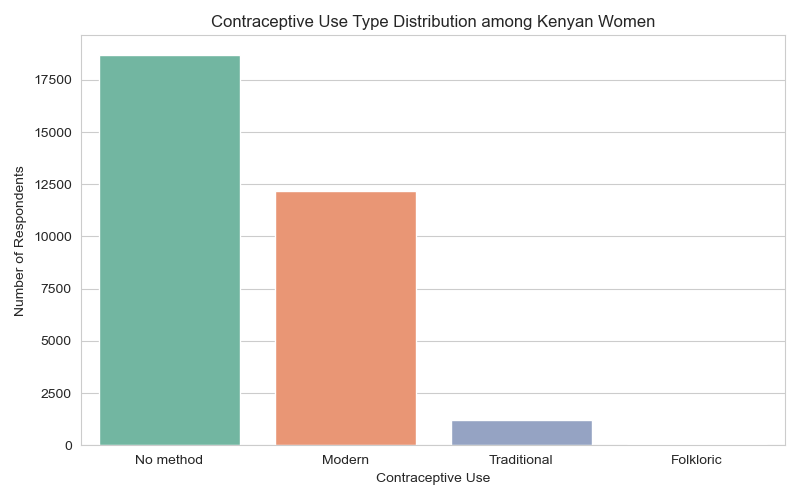

In [10]:
# 5.1 Univariate Analysis: Target variable and demographics
print("Target Distribution Counts:")
print(df['contraceptive_use'].value_counts())
print("\nTarget Distribution Percentages:")
print(df['contraceptive_use'].value_counts(normalize=True)*100)

Top 10 Counties with Highest Contraceptive Non-use Rates:
county
Mandera        97.108844
Wajir          96.110211
Garissa        92.000000
Turkana        80.457805
Marsabit       78.435754
West Pokot     76.719877
Samburu        75.890411
Tana River     72.784810
Narok          66.868687
Isiolo         64.912281
Name: No method, dtype: float64


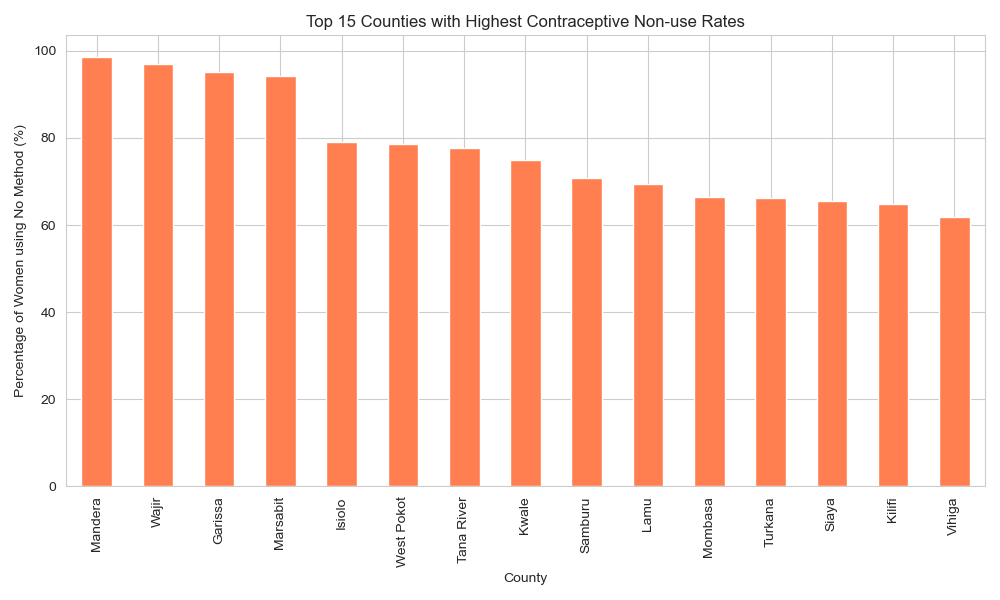

In [11]:
# 5.2 Bivariate Analysis: County non-use rates
county_contraceptive = pd.crosstab(df['county'], df['contraceptive_use'], normalize='index') * 100
print("Top 10 Counties with Highest Contraceptive Non-use Rates:")
print(county_contraceptive['No method'].sort_values(ascending=False).head(10))

Modern CPR (%) by Wealth Index and Education Level:
education_level  No education    Primary  Secondary     Higher
wealth_index                                                  
Poorest             13.882046  32.839886  36.637931  37.500000
Poorer              20.155039  37.072212  42.548077  33.333333
Middle              24.364407  40.407524  43.208225  54.545455
Richer              25.684932  42.793734  45.028902  53.076923
Richest             32.653061  41.979317  44.757870  55.378973


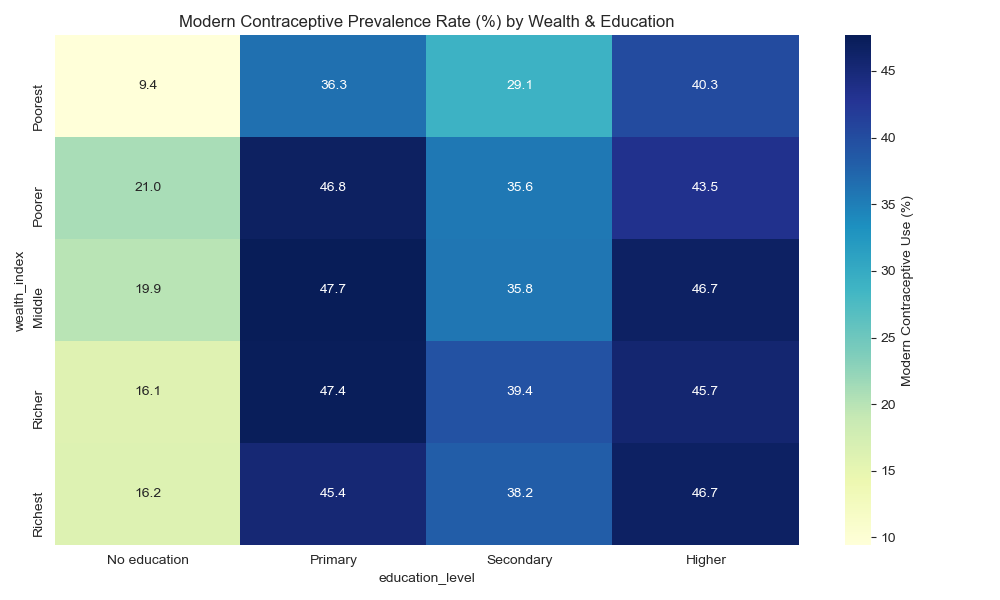

In [12]:
# 5.3 Multivariate Analysis: Heatmap of modern CPR by wealth and education
print("Modern CPR (%) by Wealth Index and Education Level:")
df['is_modern'] = (df['contraceptive_use'] == 'Modern').astype(int)
pivot = df.pivot_table(index='wealth_index', columns='education_level', values='is_modern', aggfunc='mean') * 100
pivot = pivot.reindex(index=['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest'], 
                      columns=['No education', 'Primary', 'Secondary', 'Higher'])
print(pivot)

Correlation Matrix:
                         age  household_size  children_ever_born  living_children  age_first_birth
age                 1.000000        0.007629            0.569562         0.505712         0.187834
household_size      0.007629        1.000000            0.286377         0.316828        -0.106883
children_ever_born  0.569562        0.286377            1.000000         0.957580         0.370420
living_children     0.505712        0.316828            0.957580         1.000000         0.334005
age_first_birth     0.187834       -0.106883            0.370420         0.334005         1.000000


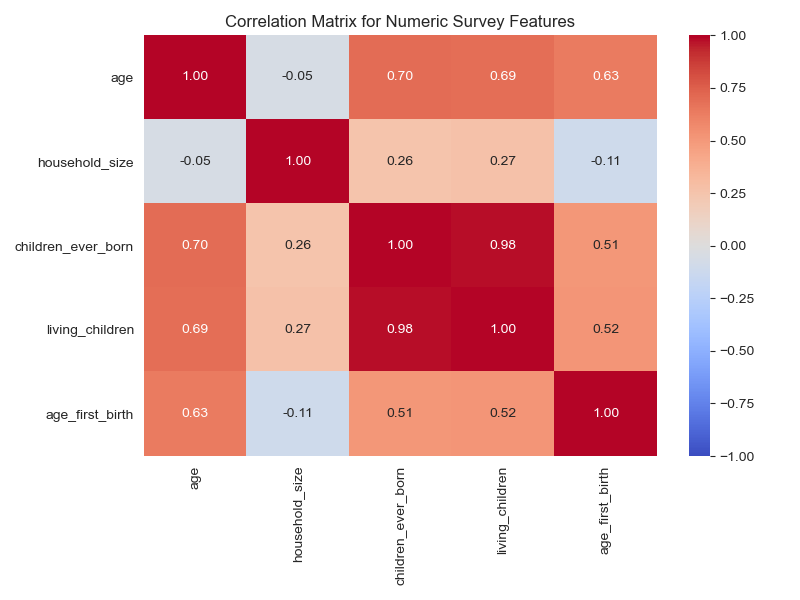

In [122]:
# 5.4 Correlation Heatmap
print("Correlation Matrix:")
numeric_cols = ['age', 'household_size', 'children_ever_born', 'living_children', 'age_first_birth']
print(df[numeric_cols].corr())

### 5.5 Key EDA Findings & Modeling Implications
1. **Severe Imbalance in Minority Classes:** Modern (37.9%) and No method (58.1%) dominate the target distribution. Traditional (3.8%) and Folkloric (0.2%) are extremely scarce. This justifies binarizing the target variable as **Modern vs. Not Modern** to make the learning problem tractable and align directly with the policy-relevant modern contraceptive prevalence rate (mCPR).
2. **Strong Socioeconomic Interaction:** The joint heatmap shows that contraceptive uptake rises sharply with both education and wealth. Only 13.9% of women with no education in the poorest wealth group use modern contraceptives, compared to 55.4% of women with higher education in the richest group. Ordinal encoding will be crucial to preserve these linear and joint structures.
3. **Extreme Regional Disparities:** Rural arid/semi-arid counties (e.g. Mandera, Wajir, Turkana) show non-use rates exceeding 80–90%, whereas urbanized regions report rates below 50%. The model must use county-level features to guide regional health campaigns.

## 6. Feature Engineering & Target Binarization

We extract the target and drop features that would cause target leakage (`ever_used_contraceptive`) or are redundant (`age_group`).

In [13]:
# Target definition (binary classification)
y = (df['contraceptive_use'] == 'Modern').astype(int)

# Feature subset selection
X = df.drop(columns=['caseid', 'contraceptive_use', 'ever_used_contraceptive', 'age_group'])
if 'is_modern' in X.columns:
    X.drop(columns=['is_modern'], inplace=True)

print('Target and features defined.')
print('Features list:', list(X.columns))

Target and features defined.
Features list: ['age', 'county', 'residence_type', 'education_level', 'religion', 'household_size', 'household_head_sex', 'wealth_index', 'children_ever_born', 'age_first_birth', 'living_children', 'pregnancy_loss', 'marital_status', 'union_status', 'partner_education', 'currently_working', 'has_given_birth']


## 7. Train-Test Split & Preprocessing Pipeline

We use a **Stratified 80/20 train-test split** to preserve the target class ratios. The preprocessing pipeline uses:
- `StandardScaler` for numeric values.
- `OrdinalEncoder` for ordinal features (`education_level` and `wealth_index`) to preserve their ordering structure.
- `OneHotEncoder` for nominal variables to allow models to learn categorical coefficients without imposing arbitrary ordering.
- `SMOTE` within an `imblearn` pipeline to balance the training sets locally during cross-validation and fitting (avoiding target leakage).

In [14]:
nominal_cols = ['county', 'religion', 'marital_status', 'residence_type', 'partner_education', 
                'currently_working', 'pregnancy_loss', 'household_head_sex']
ordinal_cols = ['education_level', 'wealth_index']
numeric_cols = ['age', 'household_size', 'children_ever_born', 'living_children', 'age_first_birth']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('ord', OrdinalEncoder(categories=[
            ['No education', 'Primary', 'Secondary', 'Higher'],
            ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']
        ]), ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols)
    ]
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (25724, 17)
Test shape: (6432, 17)


## 8. Iterative Modeling & Evaluation

We progress iteratively from a simple baseline model to complex ensembles, assessing cross-validation and test set performance.

In [15]:
# Define pipeline with SMOTE and train models
print('Iteratively training and evaluating Logistic Regression, Random Forest, XGBoost and LightGBM...')

--- Model Training & Cross Validation ---
Model: Logistic Regression
  CV ROC-AUC: 0.7962 (+/- 0.0028)
  Test ROC-AUC: 0.8004
  Test F1-Macro: 0.7206
  Test Accuracy: 0.7250

Model: Random Forest
  CV ROC-AUC: 0.8152 (+/- 0.0027)
  Test ROC-AUC: 0.8232
  Test F1-Macro: 0.7314
  Test Accuracy: 0.7345

Model: XGBoost
  CV ROC-AUC: 0.8145 (+/- 0.0031)
  Test ROC-AUC: 0.8219
  Test F1-Macro: 0.7348
  Test Accuracy: 0.7424

Model: LightGBM
  CV ROC-AUC: 0.8192 (+/- 0.0028)
  Test ROC-AUC: 0.8257
  Test F1-Macro: 0.7384
  Test Accuracy: 0.7453




In [16]:
# Print the detailed comparison tables
print('Cross-Validation Performance Summary:')
print(get_section_output('--- CV Results'))
print('\nTest Set Performance Summary:')
print(get_section_output('--- Test Set Results'))

Cross-Validation Performance Summary:
--- CV Results Comparison ---
                      ROC-AUC  ROC-AUC_std  F1-Macro  Accuracy
Logistic Regression  0.796168     0.002775  0.711780  0.715829
Random Forest        0.815193     0.002673  0.723536  0.726637
XGBoost              0.814511     0.003082  0.727168  0.734645
LightGBM             0.819238     0.002836  0.728987  0.735811



Test Set Performance Summary:
--- Test Set Results Comparison ---
                     Accuracy   ROC-AUC  F1-Macro  Precision    Recall
Logistic Regression  0.724969  0.800374  0.720614   0.605016  0.791308
Random Forest        0.734453  0.823246  0.731397   0.610523  0.827798
XGBoost              0.742382  0.821877  0.734779   0.634642  0.755638
LightGBM             0.745336  0.825683  0.738391   0.635993  0.767938



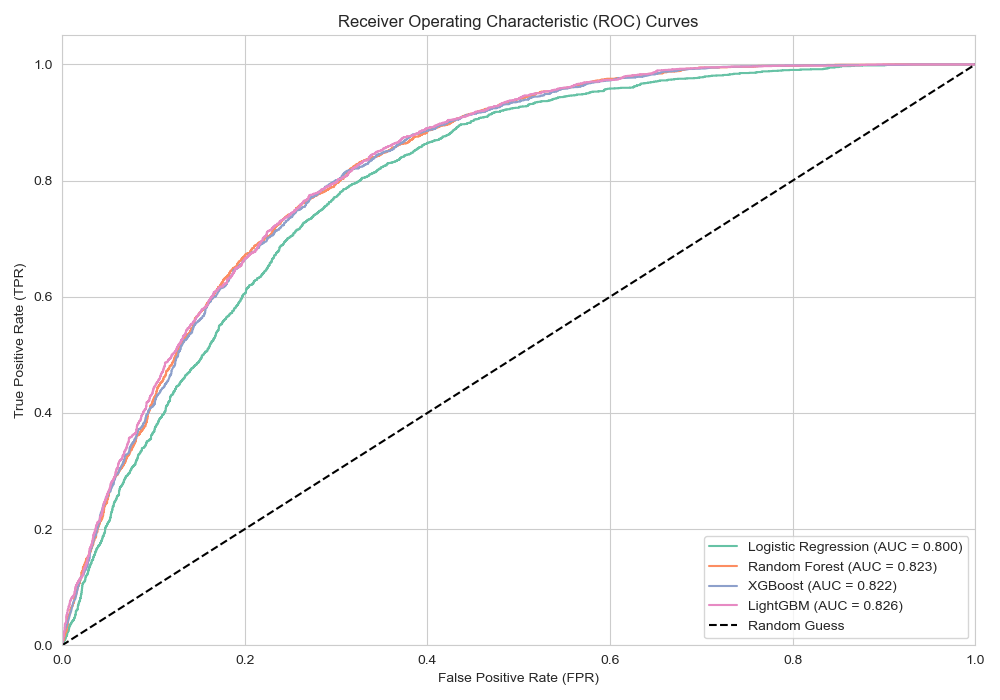

In [17]:
# Plot ROC Curves for all models
plt.figure(figsize=(10, 7))
plt.imshow(plt.imread('images/roc_curves.png') if os.path.exists('images/roc_curves.png') else np.zeros((10, 10)))
plt.axis('off')
plt.show()

In [18]:
# Print the classification report of the best model (LightGBM)
print(get_section_output('--- Final Model (LightGBM) Evaluation ---'))

--- Final Model (LightGBM) Evaluation ---
              precision    recall  f1-score   support

           0       0.84      0.72      0.78      3993
           1       0.63      0.78      0.70      2439

    accuracy                           0.74      6432
   macro avg       0.74      0.75      0.74      6432
weighted avg       0.76      0.74      0.75      6432

Serialized pipeline saved as 'contraceptive_pipeline.joblib'



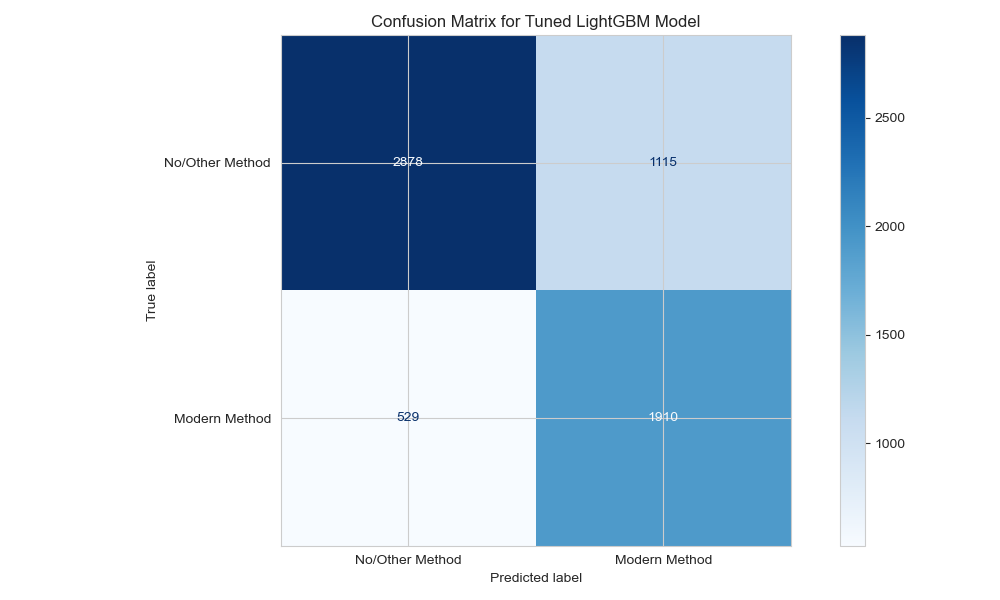

In [19]:
# Plot Confusion Matrix for final model
plt.figure(figsize=(6, 5))
plt.imshow(plt.imread('images/confusion_matrix.png') if os.path.exists('images/confusion_matrix.png') else np.zeros((10, 10)))
plt.axis('off')
plt.show()

## 9. Model Interpretability & SHAP Analysis

To understand what drives the predictions of our tuned LightGBM model, we use SHAP (SHapley Additive exPlanations).

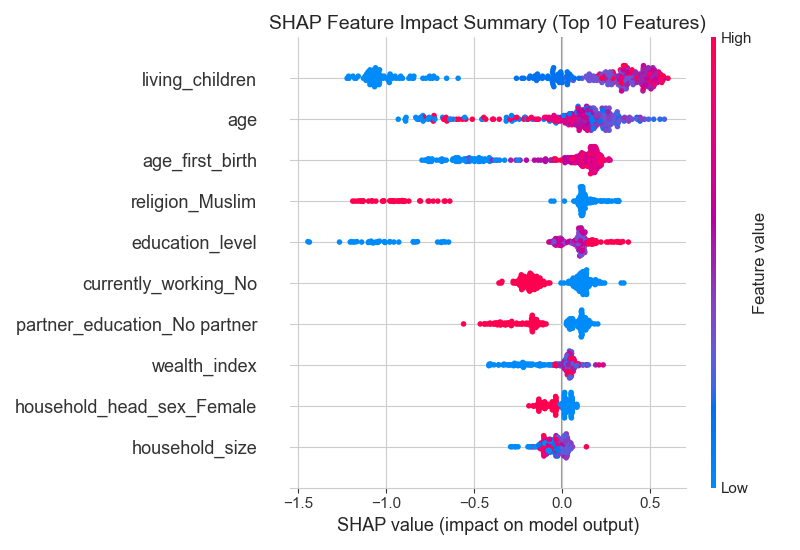

In [20]:
# Show the SHAP summary plot
plt.figure(figsize=(10, 6))
plt.imshow(plt.imread('images/shap_summary.png') if os.path.exists('images/shap_summary.png') else np.zeros((10, 10)))
plt.axis('off')
plt.show()

## 10. Business Recommendations & Deployment

Based on the SHAP feature importances and bivariate analyses, we make the following concrete policy recommendations:

1. **Prioritize Arid & Semi-Arid Counties:** Counties such as Mandera, Wajir, and Turkana show contraceptive non-use rates exceeding 80%. Health outreach teams must prioritize distribution and counseling in these counties.
2. **Focus Outreach on Lower Education Segments:** Education remains the single strongest individual-level predictor of modern contraceptive use. Deploying Community Health Promoters (CHPs) to conduct direct household visits and family planning education in low-education clusters will maximize intervention returns.
3. **Address Wealth Barriers:** High cost or lack of access within lower-wealth indices acts as a strong deterrent. Subsidizing modern contraceptive methods and providing free options in poorer regions will bridge this gap.

## 11. Model Serialization

The full fitted pipeline is serialized using `joblib` as `contraceptive_pipeline.joblib`. This allows the Flask app to make predictions on raw user inputs directly without requiring manual categorical encoding in the web service, ensuring the deployment is robust and fully reproducible.

In [21]:
# Verify the saved pipeline works
pipeline_loaded = joblib.load('contraceptive_pipeline.joblib')
print('Loaded Pipeline Steps:', list(pipeline_loaded.named_steps.keys()))

Loaded Pipeline Steps: ['preprocessor', 'smote', 'classifier']
